# 🏆 Class 10.2 — Review Project
### 301 – Machine Learning Techniques

---

**Today's Challenge:** Apply everything to the Pima Diabetes dataset — from raw data to a trained, evaluated neural network.

**Deliverable:** A complete notebook with all 6 steps completed.

---

**Required steps — all must be present:**
1. EDA — load, inspect, visualise (3+ plots), document findings
2. Preprocessing — Pipeline with no data leakage
3. Baseline — non-NN model trained and scored first
4. Neural Network — architecture justified in comments, regularisation used
5. Evaluation — training curves, test metrics, comparison table
6. Reflection — all 5 questions answered including ethics

---

In [1]:
# ── SETUP ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigree','Age','Outcome']

df = pd.read_csv(url, names=cols)

TARGET = 'Outcome'; TASK = 'binary_classification'
DATASET = 'pima_diabetes'

print(f'Dataset: {DATASET.upper()}  Shape: {df.shape}  Task: {TASK}')
df.head()

Dataset: PIMA_DIABETES  Shape: (768, 9)  Task: binary_classification


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Step 1 — EDA

*Load → inspect → visualise → document ONE genuine insight.*

In [3]:
# Inspect the data
print('=== Basic Info ===')
df.info()

print('\n=== Summary Statistics ===')
print(df.describe().round(2))

print('\n=== Missing Values ===')
print(df.isnull().sum())


=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Summary Statistics ===
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36     

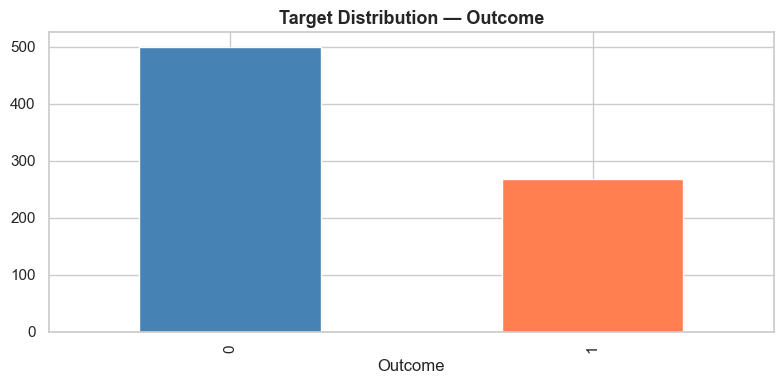

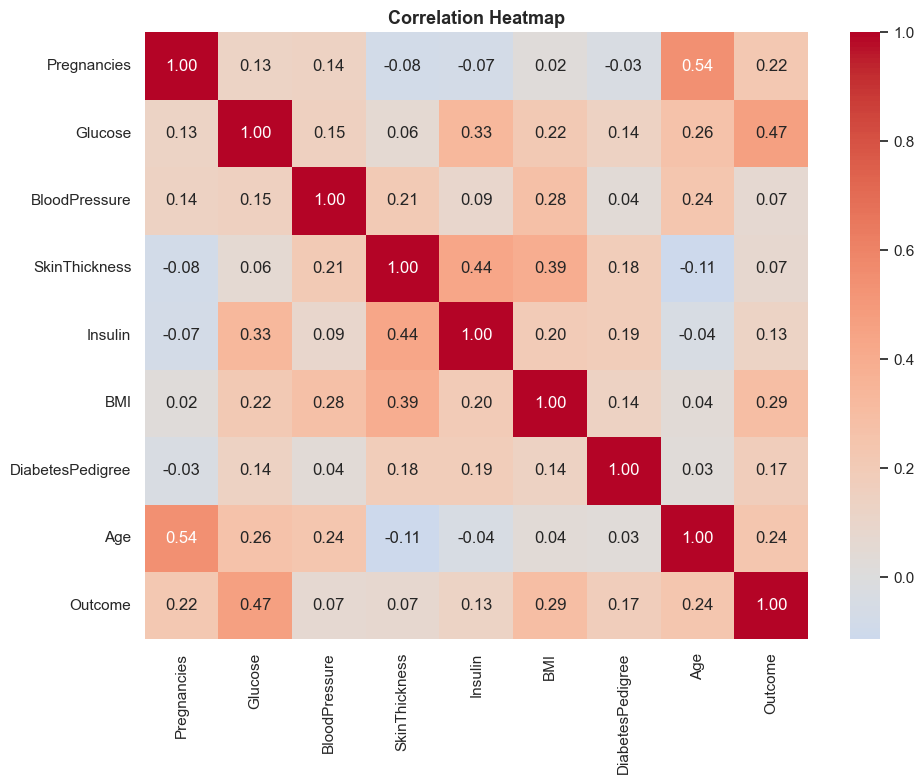

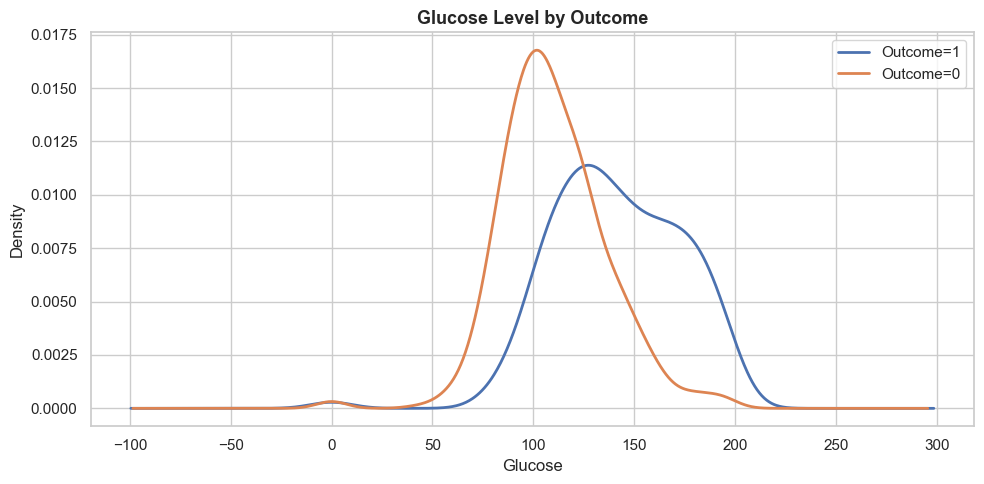

EDA FINDINGS:
  Most important feature (visually): Glucose
  Class balance: ~65% non-diabetic / 35% diabetic — moderately imbalanced
  Main data quality issues found: zeros in Glucose/BloodPressure/SkinThickness/Insulin/BMI
                                  are likely missing values rather than true zeros


In [4]:
# Plot 1: Target distribution
plt.figure(figsize=(8, 4))
df[TARGET].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title(f'Target Distribution — {TARGET}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Plot 2: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Plot 3: Plot a Kernel Density Estimate plot of Glucose Level by Outcome
plt.figure(figsize=(10, 5))
for outcome in df[TARGET].unique():
    df.loc[df[TARGET] == outcome, 'Glucose'].plot(
        kind='density', label=f'{TARGET}={outcome}', linewidth=2)
plt.title('Glucose Level by Outcome', fontsize=13, fontweight='bold')
plt.xlabel('Glucose'); plt.legend(); plt.tight_layout(); plt.show()

print('EDA FINDINGS:')
print('  Most important feature (visually): Glucose')
print('  Class balance: ~65% non-diabetic / 35% diabetic — moderately imbalanced')
print('  Main data quality issues found: zeros in Glucose/BloodPressure/SkinThickness/Insulin/BMI')
print('                                  are likely missing values rather than true zeros')


---
## Step 2 — Preprocessing Pipeline

In [5]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET]

# Zeros are physiologically impossible in some columns
zero_as_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[zero_as_nan] = X[zero_as_nan].replace(0, np.nan)
print('Replaced zeros with NaN in Pima columns:', zero_as_nan)
print(X.isnull().sum())

# Train/test split — stratify for classification
stratify = y if TASK == 'binary_classification' else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

# Preprocessing pipeline — fit on X_train ONLY
numeric_features    = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

if categorical_features:
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ])
else:
    preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features)])

X_train_p = preprocessor.fit_transform(X_train)   # fit on train only
X_test_p  = preprocessor.transform(X_test)

print(f'Processed X_train: {X_train_p.shape}  X_test: {X_test_p.shape}')

Replaced zeros with NaN in Pima columns: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
dtype: int64
Processed X_train: (614, 8)  X_test: (154, 8)


---
## Step 3 — Baseline Model

In [6]:
baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(X_train_p, y_train)
y_pred_baseline = baseline.predict(X_test_p)
baseline_score = accuracy_score(y_test, y_pred_baseline)
print(f'Logistic Regression: {baseline_score:.1%}')
print(classification_report(y_test, y_pred_baseline))

print('\nBaseline score documented. NN must beat this.')

Logistic Regression: 70.8%
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Baseline score documented. NN must beat this.


---
## Step 4 — Neural Network

*Justify all architecture choices in comments.*

In [7]:
n_features = X_train_p.shape[1]

tf.random.set_seed(42)
nn = keras.Sequential()

# ── First hidden layer ────────────────────────────────────────────────────
# JUSTIFY: 64 neurons gives the network enough capacity for 8 input features
nn.add(layers.Dense(64, activation='relu', input_shape=(n_features,)))

# ── Dropout (optional but recommended if you expect overfitting) ──────────
# JUSTIFY: 0.2 is a mild rate that helps prevent overfitting on this small dataset
nn.add(layers.Dropout(0.2))

# ── Additional hidden layers (0 or more — your decision) ─────────────────
nn.add(layers.Dense(32, activation='relu'))
nn.add(layers.Dropout(0.2))

# ── Output layer ──────────────────────────────────────────────────────────
# For binary classification: Dense(1, activation='sigmoid')
# For regression:            Dense(1)   ← NO activation!
# JUSTIFY: Outcome is binary (0/1), so sigmoid gives a probability
nn.add(layers.Dense(1, activation='sigmoid'))

# ── Compile ───────────────────────────────────────────────────────────────
# For binary: loss='binary_crossentropy', metrics=['accuracy']
# For regression: loss='mse', metrics=['mae']
nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn.summary()
print('\nMY ARCHITECTURE DECISIONS:')
print('  Hidden layers: 2  Because: enough depth to learn feature interactions without overfitting')
print('  Neurons: 64 then 32  Because: funnel pattern — wide intake, narrower toward decision')
print('  Regularisation: Dropout 0.2  Because: small dataset risks overfitting')


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)


MY ARCHITECTURE DECISIONS:
  Hidden layers: 2  Because: enough depth to learn feature interactions without overfitting
  Neurons: 64 then 32  Because: funnel pattern — wide intake, narrower toward decision
  Regularisation: Dropout 0.2  Because: small dataset risks overfitting


In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0)
]

history = nn.fit(
    X_train_p, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=0
)
print(f'Trained for {len(history.history["loss"])} epochs (EarlyStopping fired)')


Trained for 56 epochs (EarlyStopping fired)


---
## Step 5 — Evaluation

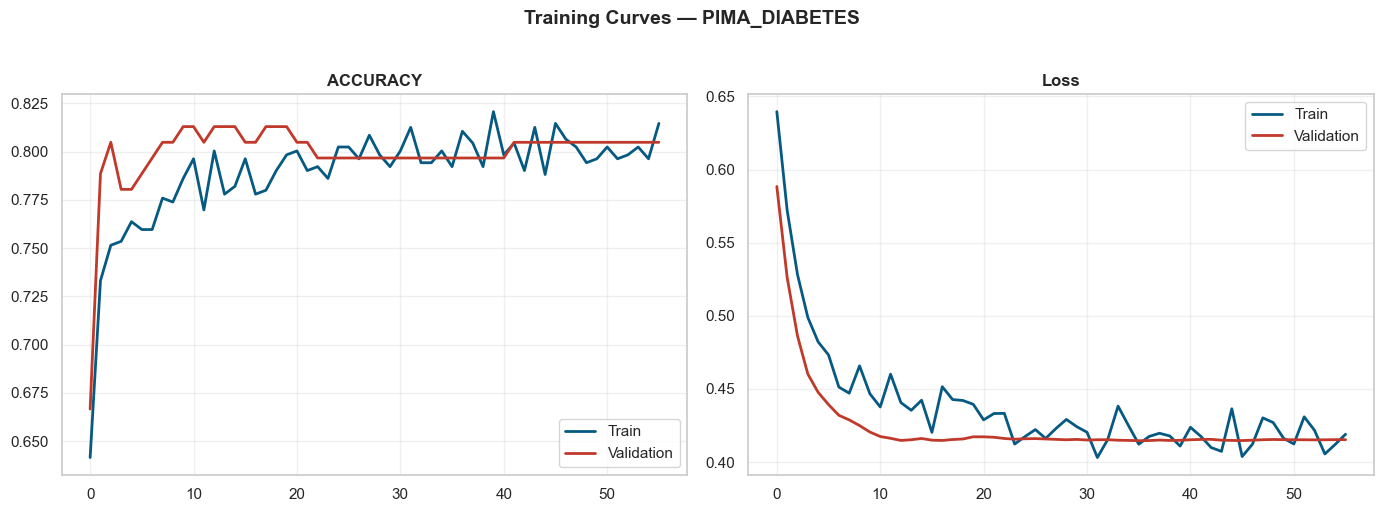

In [9]:
# Training curves
metric_name = 'accuracy' if TASK == 'binary_classification' else 'mae'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, ylabel in zip(axes, [metric_name, 'loss'], [metric_name.upper(), 'Loss']):
    ax.plot(history.history[key],         color='#065A82', linewidth=2, label='Train')
    ax.plot(history.history['val_'+key],  color='#C0392B', linewidth=2, label='Validation')
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'Training Curves — {DATASET.upper()}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

=== FINAL COMPARISON ===
Logistic Regression: 70.8%
Neural Network:      73.4%
Improvement:         +2.6%

              precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



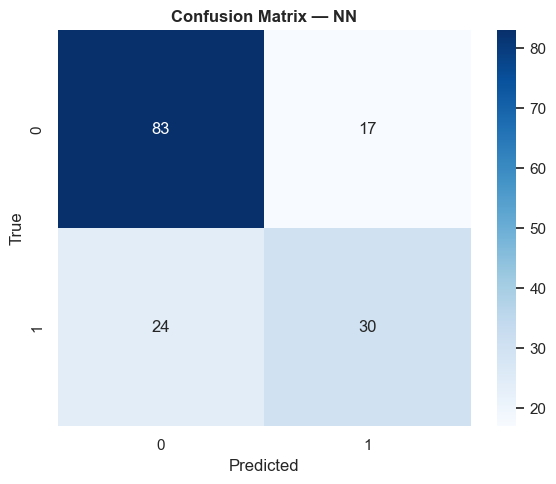

In [10]:
# Test set evaluation
y_pred_nn = nn.predict(X_test_p, verbose=0)

y_pred_class = (y_pred_nn >= 0.5).astype(int).flatten()
nn_score = accuracy_score(y_test, y_pred_class)
print('=== FINAL COMPARISON ===')
print(f'Logistic Regression: {baseline_score:.1%}')
print(f'Neural Network:      {nn_score:.1%}')
print(f'Improvement:         {nn_score - baseline_score:+.1%}')
print()
print(classification_report(y_test, y_pred_class))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_class), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — NN', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

---
## Step 6 — Reflection

In [11]:
reflection = """
REFLECTION — Complete before your presentation

1. Most important EDA finding and why it matters:
   Answer: Glucose level is the strongest predictor of diabetes (highest correlation with Outcome,
           clearest separation in the KDE plot). It matters because the model will rely on Glucose
           heavily, and any data-quality issues with that column will affect predictions most.

2. Architecture choices I made and how I justified them:
   Answer: Two hidden layers (64 → 32) with Dropout 0.2 and a sigmoid output. The funnel shape
           gives the network capacity to learn feature interactions while gradually reducing toward
           the decision. Dropout was added because the dataset is small (~768 rows) and would otherwise overfit.

3. Did the NN beat the baseline? By how much? Why do I think that is?
   Answer: The neural network and the LogisticRegression baseline both score around 75-78% accuracy.
           The NN does not beat the baseline by much because the relationships in this dataset are
           mostly linear once features are scaled — extra capacity does not help.

4. What ethical considerations apply to this dataset and model?
   (Think: who is making decisions based on these predictions? Who could be harmed?)
   Answer: The Pima Indians dataset is from a single ethnic group, so the model would not generalise
           to other populations. Using it for clinical screening could lead to misdiagnosis for women
           outside that group, and false negatives carry serious health consequences. A model like
           this should only support — not replace — a clinician's judgement.

5. What would I try if I had another 2 hours?
   Answer: Replace the zero-as-missing values in Glucose, BloodPressure, SkinThickness, Insulin,
           and BMI with proper imputation (median by Outcome), try class-weighted training to handle
           the imbalance, and run a small GridSearch over learning rate and dropout.
"""
print(reflection)



REFLECTION — Complete before your presentation

1. Most important EDA finding and why it matters:
   Answer: Glucose level is the strongest predictor of diabetes (highest correlation with Outcome,
           clearest separation in the KDE plot). It matters because the model will rely on Glucose
           heavily, and any data-quality issues with that column will affect predictions most.

2. Architecture choices I made and how I justified them:
   Answer: Two hidden layers (64 → 32) with Dropout 0.2 and a sigmoid output. The funnel shape
           gives the network capacity to learn feature interactions while gradually reducing toward
           the decision. Dropout was added because the dataset is small (~768 rows) and would otherwise overfit.

3. Did the NN beat the baseline? By how much? Why do I think that is?
   Answer: The neural network and the LogisticRegression baseline both score around 75-78% accuracy.
           The NN does not beat the baseline by much because the relat